# Spike and Recovery for Human samples

In [1]:
import sys
sys.path.insert(0, '..')

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import matplotlib
import random
import matplotlib.patches as patches

import warnings

# Set the warning filter
warnings.simplefilter("once", UserWarning)

from utils.utils import *

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
np.random.seed(1)
random.seed(42)



def clean_cals_vals(cals, vals, conc_epsilon=1e-5):
  melted_cals = {}
  calambnames = ['amb1','amb2']
  callogambnames = ['log_amb1','log_amb2']
  calmeanpnames = ['meanp1','meanp2']
  callogmeanpnames = ['log_meanp1','log_meanp2']
  calmeannames = ['mean_all1','mean_all2']
  callogmeannames = ['log_mean_all1','log_mean_all2']
  for k, df in cals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()

    #df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[calambnames], axis=1, nan_policy='omit')
    df_avg['lambda'] = stats.gmean(df[['lambda1','lambda2']], axis=1, nan_policy='omit')
    df_avg['log_amb'] = stats.gmean(df[callogambnames], axis=1, nan_policy='omit')
    df_avg['meanp'] = stats.gmean(df[calmeanpnames],  axis=1,nan_policy='omit')
    df_avg['log_meanp'] = stats.gmean(df[callogmeanpnames],  axis=1,nan_policy='omit') 
    df_avg['mean_all'] = stats.gmean(df[calmeannames],  axis=1,nan_policy='omit')
    df_avg['log_mean_all'] = stats.gmean(df[callogmeannames],  axis=1,nan_policy='omit')  

    df_final = df_avg[['conc', 'amb', 'lambda', 'meanp', 'log_amb', 'log_meanp', 'mean_all', 'log_mean_all']].copy()
    melted_cals[k] = df_final
    melted_cals[k]['amb_deviation']=np.std(df[calambnames], axis=1)
    melted_cals[k]['meanp_deviation']=np.std(df[calmeanpnames], axis=1)
    melted_cals[k]['log_amb_deviation']=np.std(df[callogambnames], axis=1)
    melted_cals[k]['log_meanp_deviation']=np.std(df[callogmeanpnames], axis=1)
    melted_cals[k]['mean_all_deviation']=np.std(df[calmeannames], axis=1)
    melted_cals[k]['log_mean_all_deviation']=np.std(df[callogmeannames], axis=1)

  melted_vals = {}
  for k, df in vals.items():
    # Average replicates in log space (geometric mean) for calibration curves
    df_avg = df.copy()
    
    df_avg['amb'] = np.nan
    df_avg['amb'] = stats.gmean(df[['amb1','amb2']], axis=1, nan_policy='omit')

    df_avg['lambda'] = np.nan
    df_avg['lambda'] = stats.gmean(df[['lambda1','lambda2']], axis=1, nan_policy='omit')

    df_avg['log_amb'] = np.nan
    df_avg['log_amb'] = stats.gmean(df[['log_amb1','log_amb2']], axis=1, nan_policy='omit')

    df_avg['meanp'] = np.nan
    df_avg['meanp'] = stats.gmean(df[['meanp1','meanp2']],  axis=1,nan_policy='omit')
    df_avg['log_meanp'] = stats.gmean(df[['log_meanp1','log_meanp2']],  axis=1,nan_policy='omit')

    df_avg['mean_all'] = np.nan
    df_avg['mean_all'] = stats.gmean(df[['mean_all1','mean_all2']],  axis=1,nan_policy='omit')

    df_avg['log_mean_all'] = np.nan
    df_avg['log_mean_all'] = stats.gmean(df[['log_mean_all1','log_mean_all2']],  axis=1,nan_policy='omit') 

    df_final = df_avg[['amb', 'lambda', 'meanp', 'log_amb', 'log_meanp', 'mean_all', 'log_mean_all']].copy()
    melted_vals[k] = df_final

  cals = melted_cals
  vals = melted_vals

  for k, df in cals.items():
    cals[k]['conc'] = df['conc'].astype(float)+conc_epsilon
    cals[k]['amb'] = df['amb'].astype(float)
    cals[k]['meanp'] = df['meanp'].astype(float)
    cals[k]['log_amb'] = df['log_amb'].astype(float)
    cals[k]['log_meanp'] = df['log_meanp'].astype(float)

  for k, df in vals.items():
    vals[k]['amb'] = df['amb'].astype(float)
    vals[k]['log_amb'] = df['log_amb'].astype(float)
    vals[k]['meanp'] = df['meanp'].astype(float)
    vals[k]['log_meanp'] = df['log_meanp'].astype(float)
  return cals, vals

In [5]:
sheet1 = pd.read_excel('../measurement_data/S&R_human.xlsx',header=None)

sheet1
il22 = sheet1.iloc[1:18,1:7]
il23 = sheet1.iloc[1:18,8:14]
il6 = sheet1.iloc[1:18,15:21]

il10 = sheet1.iloc[20:37,1:7]
il17 = sheet1.iloc[20:37,8:14]
il18 = sheet1.iloc[20:37,15:21]

tnfa = sheet1.iloc[39:56,1:7]

In [7]:
figure_path='../paper_and_outputs/figures/'

In [8]:
conc_epsilon= 1e-3 
lod_emb_epsilon=0.05
scale= 3.29
lod_reduction = 1
amb_log_constant=0

In [9]:
cals = {}
data = {}

cals['il22'] = il22.iloc[0:8,0:5]
cals['il23'] = il23.iloc[0:8,0:5]
cals['il6'] = il6.iloc[0:8,0:5]

cals['il10'] = il10.iloc[0:8,0:5]
cals['il17'] = il17.iloc[0:8,0:5]
cals['il18'] = il18.iloc[0:8,0:5]

cals['tnfa'] = tnfa.iloc[0:8,0:5]

for k,c in cals.items():
  c.columns = ['conc','amb1','amb2','meanp1','meanp2']
  c.reset_index(drop=True,inplace=True)
  c['conc'] = c['conc'].astype(float)
  c['amb1'] = c['amb1'].astype(float)
  c['amb2'] = c['amb2'].astype(float)
  c['meanp1'] = c['meanp1'].astype(float)
  c['meanp2'] = c['meanp2'].astype(float)
  cals[k] = c

for k,c in cals.items():
  c['amb1'] = pd.to_numeric(c['amb1'], errors='coerce')
  c['amb2'] = pd.to_numeric(c['amb2'], errors='coerce')
  c['meanp1'] = pd.to_numeric(c['meanp1'], errors='coerce')
  c['meanp2'] = pd.to_numeric(c['meanp2'], errors='coerce')
  cals[k] = c

for k,c in cals.items():
  c['log_amb1'] = np.log(c['amb1'])+amb_log_constant
  c['log_amb2'] = np.log(c['amb2'])+amb_log_constant
  c['log_meanp1'] = np.log(c['meanp1'])
  c['log_meanp2'] = np.log(c['meanp2'])
  c['lambda1'] = amb_to_on(c['amb1'])
  c['lambda2'] = amb_to_on(c['amb2'])
  c['mean_all1'] =c['lambda1']*c['meanp1']
  c['mean_all2'] =c['lambda2']*c['meanp2']
  c['log_mean_all1'] = np.log(c['mean_all1'])
  c['log_mean_all2'] = np.log(c['mean_all2'])
  cals[k] = c

data['il22'] = il22.iloc[11:,[0,1,2,3,4,5]]
data['il23'] = il23.iloc[11:,[0,1,2,3,4,5]]
data['il6'] = il6.iloc[11:,[0,1,2,3,4,5]]

data['il10'] = il10.iloc[11:,[0,1,2,3,4,5]]
data['il17'] = il17.iloc[11:,[0,1,2,3,4,5]]
data['il18'] = il18.iloc[11:,[0,1,2,3,4,5]]

data['tnfa'] = tnfa.iloc[11:,[0,1,2,3,4,5]]

for k,v in data.items():
  v.columns = ['sample','notes','amb1','amb2','meanp1','meanp2']
  v.reset_index(drop=True,inplace=True)
  v['sample'] = v['sample'].astype(str)
  v['amb1'] = v['amb1'].replace("not enough sample", np.nan)
  v['amb2'] = v['amb2'].replace("not enough sample", np.nan)
  v['amb1'] = v['amb1'].astype(float)
  v['amb2'] = v['amb2'].astype(float)
  v['meanp1'] = v['meanp1'].astype(float)
  v['meanp2'] = v['meanp2'].astype(float)
  data[k] = v

for k,v in data.items():
  v['amb1'] = pd.to_numeric(v['amb1'], errors='coerce')
  v['amb2'] = pd.to_numeric(v['amb2'], errors='coerce')
  v['meanp1'] = pd.to_numeric(v['meanp1'], errors='coerce')
  v['meanp2'] = pd.to_numeric(v['meanp2'], errors='coerce')
  data[k] = v

for k,v in data.items():
  v['log_amb1'] = np.log(v['amb1'])+amb_log_constant
  v['log_amb2'] = np.log(v['amb2'])+amb_log_constant
  v['log_meanp1'] = np.log(v['meanp1'])
  v['log_meanp2'] = np.log(v['meanp2'])
  v['lambda1'] = amb_to_on(v['amb1'])
  v['lambda2'] = amb_to_on(v['amb2'])
  v['mean_all1'] =v['lambda1']*v['meanp1']
  v['mean_all2'] =v['lambda2']*v['meanp2']
  v['log_mean_all1'] = np.log(v['mean_all1'])
  v['log_mean_all2'] = np.log(v['mean_all2'])
  data[k] = v

In [10]:
cals['il10']

,conc,amb1,amb2,meanp1,meanp2,log_amb1,log_amb2,log_meanp1,log_meanp2,lambda1,lambda2,mean_all1,mean_all2,log_mean_all1,log_mean_all2
0,200.0000,4.828314,4.342806,44390.0,51029.0,1.574497,1.468521,10.700769,10.840149,0.992000,0.987000,44034.880001,50365.622999,10.692737,10.827064
1,40.0000,0.818710,0.896488,13359.0,14815.0,-0.200025,-0.109270,9.499946,9.603395,0.559000,0.592000,7467.680979,8770.479972,8.918340,9.079147
2,8.0000,0.162519,0.191161,10666.0,11732.0,-1.816961,-1.654642,9.274816,9.370075,0.150000,0.174000,1599.900005,2041.368044,7.377696,7.621375
3,1.6000,0.069603,0.071174,11644.0,10900.0,-2.664951,-2.642630,9.362546,9.296518,0.067236,0.068700,782.892969,748.830006,6.662996,6.618512
4,0.3200,0.021407,0.028811,11269.0,10696.0,-3.844047,-3.546995,9.329811,9.277625,0.021179,0.028400,238.669540,303.766381,5.475080,5.716259
5,0.0640,0.016028,0.016129,11010.0,9423.0,-4.133433,-4.127113,9.306559,9.150909,0.015900,0.016000,175.058988,150.767982,5.165123,5.015742
6,0.0128,0.011878,0.010514,10318.0,11066.0,-4.433038,-4.555064,9.241645,9.311633,0.011808,0.010459,121.835820,115.736581,4.802674,4.751317
7,0.0000,0.010758,0.010872,6938.0,9522.0,-4.532137,-4.521534,8.844769,9.161360,0.010700,0.010813,74.236623,102.965574,4.307258,4.634395


In [11]:
cals,vals=clean_cals_vals(cals, data, conc_epsilon=conc_epsilon)

/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/scipy/stats/_stats_py.py:247: RuntimeWarning: invalid value encountered in log
  log_a = xp.log(a)
/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/

In [12]:
cals['il22']


,conc,amb,lambda,meanp,log_amb,log_meanp,mean_all,log_mean_all,amb_deviation,meanp_deviation,log_amb_deviation,log_meanp_deviation,mean_all_deviation,log_mean_all_deviation
0,200.0010,4.990092,0.992494,611193.095511,1.604266,13.322211,606605.375515,13.314718,0.505801,98000.0,0.101188,0.159663,95098.499890,0.156136
1,40.0010,4.167311,0.984500,232997.287916,1.427250,12.358768,229385.801060,12.343145,0.032269,4382.5,0.007743,0.018808,4431.089550,0.019316
2,8.0010,2.653414,0.929489,48387.566616,0.975550,10.786702,44975.716517,10.713543,0.063917,3869.0,0.024086,0.079874,3814.675578,0.084715
3,1.6010,0.544011,0.419314,15576.034476,NaN,9.653226,6531.244696,8.784342,0.041403,1109.5,0.076034,0.071171,91.217529,0.013966
4,0.3210,0.175773,0.161094,14573.550357,NaN,9.586335,2347.705478,7.761194,0.021382,1603.5,0.121347,0.109807,2.733587,0.001164
5,0.0650,0.096099,0.091554,12416.978135,NaN,9.426764,1136.824331,7.034561,0.017696,402.5,0.183124,0.032410,161.983867,0.142010
6,0.0138,0.035193,0.034578,12183.307022,NaN,9.407812,421.277539,6.042685,0.003574,170.5,0.101393,0.013994,36.114964,0.085623
7,0.0010,0.058213,0.056548,11084.515325,NaN,9.313150,626.808766,6.439619,0.003661,595.5,0.062854,0.053698,72.077260,0.114739


/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:152: OptimizeWarning: Covariance of the parameters could not be estimated
  params, _ = curve_fit(log5pl, x, y, p0=p0, maxfev=100000, xtol=1e-03)#, ftol=1e-03, xtol=1e-08, gtol=0)


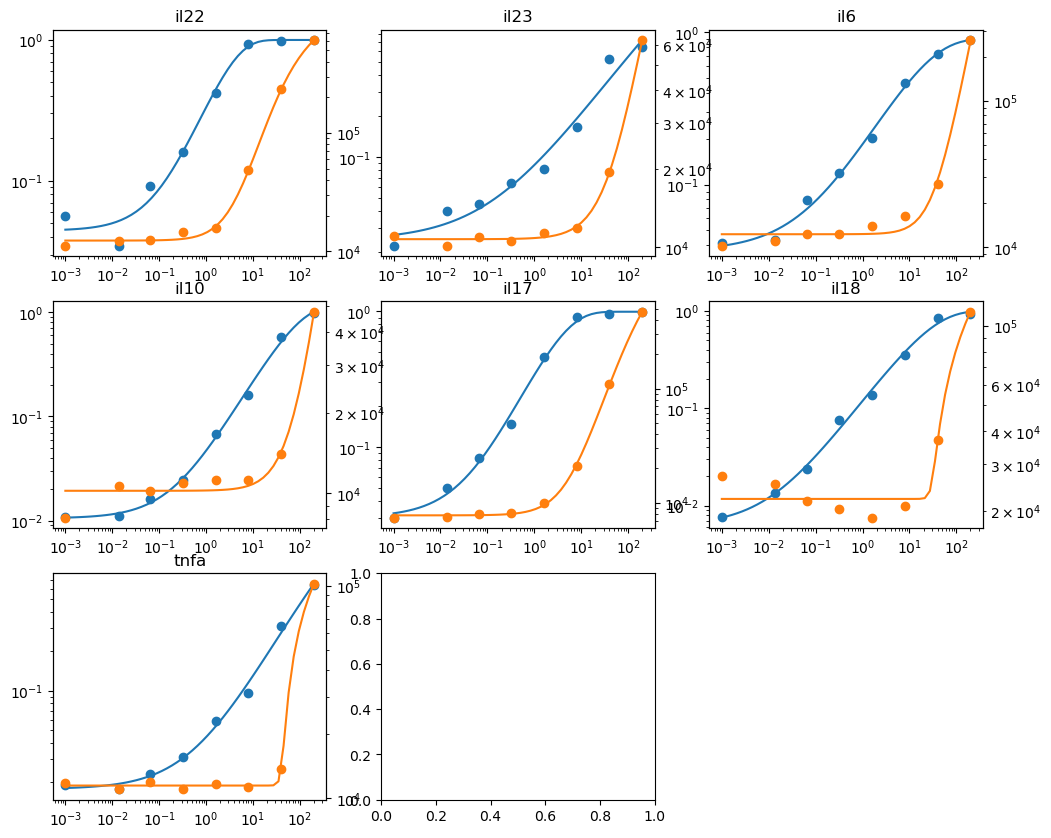

In [13]:
params = {} 
conclimits = {}
measurelimits = {}
llod = {}
llod_conc = {}
llod_conc_ll = {}
ulod = {}
ulod_conc = {}
ulod_conc_ll = {}
xf={}
yf={}
fig, axes = plt.subplots(3,3, figsize=(12, 10))
axes = axes.flatten()
axes2 = axes.copy()

ambval='lambda'
meanval='meanp'

for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)
  xf[k, meanval],yf[k, meanval],params[k, meanval] = cal_curve_fit(df, x_var='conc', y_var=meanval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]
  meanp_at_min_conc = df[df['conc'] == min_nonzero_conc][meanval]

  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))
  measurelimits[k,meanval] = (min(meanp_at_min_conc), max(df[meanval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='tab:blue')

  axes2[i] = axes[i].twinx()
  
  axes2[i].plot(xf[k,meanval],yf[k,meanval], color='tab:orange')
  
  axes[i].scatter(df['conc'],df[ambval], color='tab:blue')
  axes2[i].scatter(df['conc'],df[meanval], color='tab:orange')
  #
  axes[i].set_yscale('log')
  axes2[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(k)
axes[8].remove()

<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_88635/3977785146.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel('fraction of on beads ($\lambda$)')


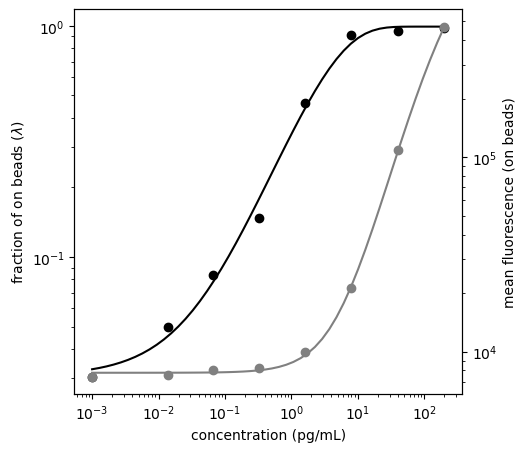

In [14]:

fig, ax = plt.subplots( figsize=(5, 5))
#axes2 = axes.copy()

ambval='lambda'
meanval='meanp'

for i, (k, df) in enumerate(cals.items()):
  if k=='il17':
    ax.plot(xf[k,ambval],yf[k,ambval], color='black')
    ax2 = ax.twinx()
    ax2.plot(xf[k,meanval],yf[k,meanval], color='gray')

    ax.scatter(df['conc'],df[ambval], color='black')
    ax2.scatter(df['conc'],df[meanval], color='gray')
    #
    ax.set_yscale('log')
    ax2.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylabel('fraction of on beads ($\lambda$)')
    ax2.set_ylabel('mean fluorescence (on beads)')
    ax.set_xlabel('concentration (pg/mL)')


In [15]:

for k,v in vals.items():
  v['calculated_conc_amb'] = v[ambval].apply(invlog5pl_after_lod, superparams=(params[k,ambval],conclimits[k],measurelimits[k, ambval]))
  v['calculated_conc_mean'] = v[meanval].apply(invlog5pl_after_lod, superparams=(params[k,meanval],conclimits[k],measurelimits[k, meanval]))
  # chose calculated_conc from amb if amb is below 0.1
  v['calculated_conc'] = np.where(v[ambval]<100, v['calculated_conc_amb'], v['calculated_conc_mean'])
  vals[k] = v

for k,v in vals.items():
  _=v['calculated_conc'] 
  print([_[0]-_[0], _[1]-_[0], _[2]-_[0],_[3]-_[3], _[4]-_[3],_[5]-_[3]])
  v['corrected']=[_[0]-_[0], _[1]-_[0], _[2]-_[0],_[3]-_[3], _[4]-_[3],_[5]-_[3]]
  v['true'] =[0, 40, 1.6, 0, 40, 1.6 ]
  v['error'] = (v['corrected'] - v['true'])
  v['relative_error'] = v['error']/v['true']
  v['abs relative_error'] = np.abs(v['relative_error'])
  v['percent_recovery'] = (v['corrected']/v['true'])*100
  v['calculated_conc_recover'] = (v['calculated_conc']/v['true'])*100 # we need to subtract the baseline but based on the baseline from the AMB and not gmean
  vals[k] = v


[np.float64(0.0), np.float64(14.53987570862175), np.float64(1.8676628680596155), np.float64(0.0), np.float64(12.55066859662257), np.float64(1.3383791473975761)]
[np.float64(nan), np.float64(nan), np.float64(nan), np.float64(0.0), np.float64(131.7934681959736), np.float64(1.018293794118424)]
[np.float64(0.0), np.float64(46.51209675985684), np.float64(2.585432783233398), np.float64(0.0), np.float64(56.45589109035108), np.float64(1.8885514825881358)]
[np.float64(0.0), np.float64(45.91155610354308), np.float64(1.8939331263623422), np.float64(0.0), np.float64(45.45561115257062), np.float64(2.2827491328878353)]
[np.float64(0.0), np.float64(14.851465409247604), np.float64(2.0186260333851465), np.float64(0.0), np.float64(13.188798127331381), np.float64(1.4539236406839848)]
[np.float64(0.0), np.float64(64.33211643959604), np.float64(1.5897097220719902), np.float64(0.0), np.float64(91.97857089859525), np.float64(1.7139807389902861)]
[np.float64(0.0), np.float64(52.72104680287113), np.float64(2.6

/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encountered in log
  logx = np.log(C) + (1/B) * np.log(((A - D) / (y - D)) ** (1/G) - 1)
/Users/teg14/Library/CloudStorage/Dropbox/Walt:Gibson lab shared folder/final_paper/v3_github_and_preprint/github_repo/notebooks/../utils/utils.py:64: RuntimeWarning: invalid value encounter

/opt/anaconda3/envs/cocktail/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


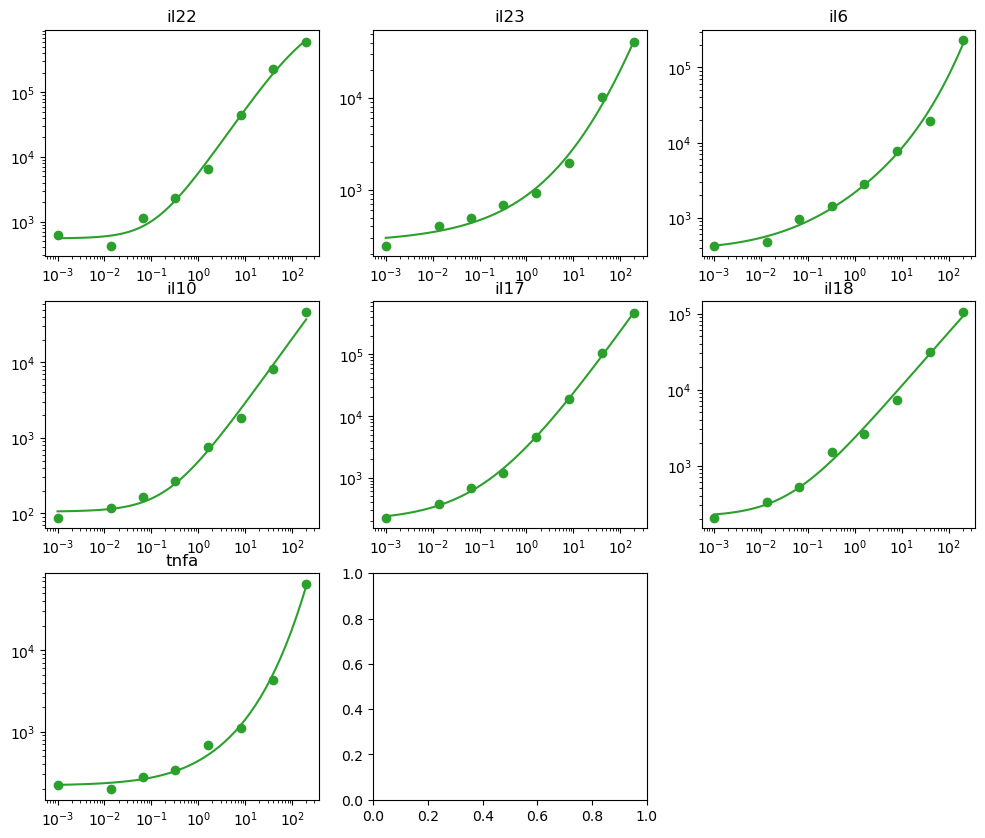

In [16]:
#params = {} 
#conclimits = {}
#measurelimits = {}
#llod = {}
#llod_conc = {}
#llod_conc_ll = {}
#ulod = {}
#ulod_conc = {}
#ulod_conc_ll = {}
#xf={}
#yf={}
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
axes2 = axes.copy()

ambval='mean_all'
meanval='amb'
deviation='mean_all_deviation'

for i, (k, df) in enumerate(cals.items()):
  xf[k, ambval], yf[k, ambval], params[k, ambval] = cal_curve_fit(df, x_var='conc', y_var=ambval)
  xf[k, meanval],yf[k, meanval],params[k, meanval] = cal_curve_fit(df, x_var='conc', y_var=meanval)

  # Get lowest non-zero concentration
  min_nonzero_conc = min(df[df['conc'] > 0]['conc'])
  amb_at_min_conc = df[df['conc'] == min_nonzero_conc][ambval]
  meanp_at_min_conc = df[df['conc'] == min_nonzero_conc][meanval]

  conclimits[k] = (min_nonzero_conc, max(df['conc']))
  measurelimits[k,ambval] = (min(amb_at_min_conc), max(df[ambval]))
  measurelimits[k,meanval] = (min(meanp_at_min_conc), max(df[meanval]))

  axes[i].plot(xf[k,ambval],yf[k,ambval], color='tab:green')
  
  axes[i].scatter(df['conc'],df[ambval], color='tab:green')
  #xes2[i].scatter(df['conc'],df[meanval], color='tab:orange')
  axes[i].set_yscale('log')
  #axes2[i].set_yscale('log')
  axes[i].set_xscale('log')
  axes[i].set_title(k)
axes[8].remove()


<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_88635/3602847800.py:11: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(xf[k,ambval],yf[k,ambval], color='black', label='$\lambda$')
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_88635/3602847800.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax2.plot(xf[k,meanval],yf[k,meanval], color=gray, label= '$\mu$')
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_88635/3602847800.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


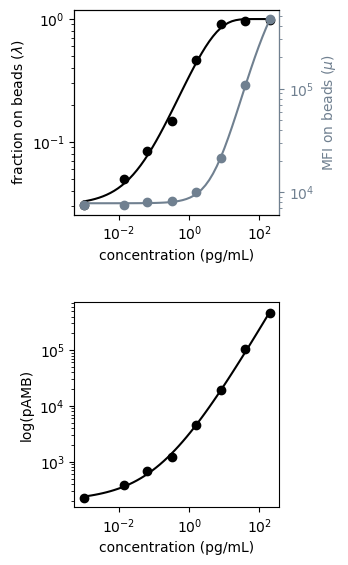

In [17]:
fig, axes = plt.subplots(2,1, figsize=(3.2, 6), layout='constrained')

ambval='lambda'
meanval='meanp'

gray='slategray'

for i, (k, df) in enumerate(cals.items()):
  if k=='il17':
    ax=axes[0]
    ax.plot(xf[k,ambval],yf[k,ambval], color='black', label='$\lambda$')
    ax2 = ax.twinx()
    ax2.plot(xf[k,meanval],yf[k,meanval], color=gray, label= '$\mu$')

    ax.scatter(df['conc'],df[ambval], color='black')
    ax2.scatter(df['conc'],df[meanval], color=gray)
    #
    ax.set_yscale('log')
    ax2.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylabel(r'fraction on beads ($\lambda$)')
    ax2.set_ylabel(r'MFI on beads ($\mu$)', color=gray)
    ax.set_xlabel('concentration (pg/mL)')

    # Match MFI axis spine, tick marks, and tick labels to dark gray color
    ax2.tick_params(axis='y', colors=gray, which='both')
    ax2.spines['right'].set_color(gray)

    # Add legend
    #lines1, labels1 = ax.get_legend_handles_labels()
    #lines2, labels2 = ax2.get_legend_handles_labels()
    #ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    ambval='mean_all'
    
    ax=axes[1]

    ax.plot(xf[k,ambval],yf[k,ambval], color='black')
    ax.scatter(df['conc'],df[ambval], color='black')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel('log(pAMB)')
    ax.set_xlabel('concentration (pg/mL)')


axes[0].set_box_aspect(1)
axes[1].set_box_aspect(1)
plt.tight_layout()

fig.savefig(figure_path+'schematic_digital_analog.pdf')

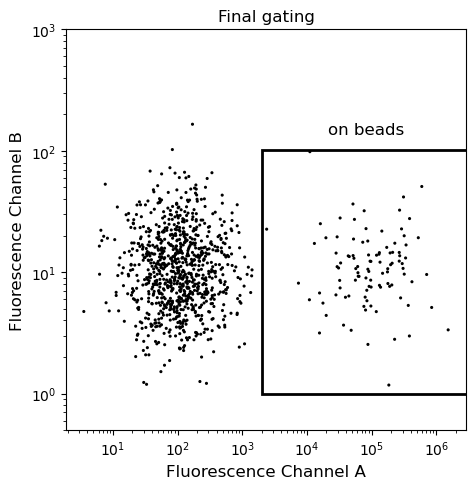

In [18]:

# 1. Generate sample data resembling flow cytometry plots
# We'll create three distinct populations.
np.random.seed(42)
num_points = 1000

# Population 1 (dim/dim)
p1 = np.random.multivariate_normal([2, 1], [[.2, 0], [0, 0.1]], size=int(num_points*0.9))
# Population 2 (bright/dim)
p2 = np.random.multivariate_normal([5, 1], [[.2, 0], [0, 0.1]], size=int(num_points*0.1))
# Population 3 (bright/bright)
#p3 = np.random.multivariate_normal([7, 8], [[0.2, -0.1], [-0.1, 0.2]], size=int(num_points*0.15))

# Combine the populations
data = np.concatenate((p1, p2), axis=0)
x, y = data.T

x=10**x
y=10**y


# 3. Create the plot with a FlowJo-like style
fig, ax = plt.subplots(figsize=(5, 5))


# Create the scatter plot with color mapped to density
ax.scatter(x, y, s=5, marker='o', edgecolors='none', color='k')

# 4. Customize the plot to mimic FlowJo's appearance
ax.set_facecolor('white')
ax.grid(False)

# Set axes labels and logicle-like scaling
ax.set_xlabel('Fluorescence Channel A', fontsize=12)
ax.set_ylabel('Fluorescence Channel B', fontsize=12)
ax.set_title('Final gating', fontsize=12)

# Create a color bar for the density scale
#cbar = fig.colorbar(ax.collections[0], ax=ax)
#cbar.set_label('Population Density', fontsize=12)

# Set logarithmic scaling for the axes, which is common in flow cytometry
# and can be replicated with a custom SymLogNorm for visualizing events near zero.
# Here, we will use a standard log scale for simplicity.
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', which='both', labelsize=10)


rect1 = patches.Rectangle((2*10**3, 1), 4*10**6, 100, linewidth=2, edgecolor='black', facecolor='none')
ax.add_patch(rect1)

ax.text(0.75, 0.75, 'on beads', horizontalalignment='center',
     verticalalignment='center', transform=ax.transAxes, fontsize=12)

# Adjust plot limits for better visualization
#ax.set_xlim(-4, 14)
ax.set_ylim(.5, 10**3)
ax.set_box_aspect(1)

plt.tight_layout()
plt.savefig(figure_path+'flowjo_like_density_plot.pdf')

plt.show()


<>:50: SyntaxWarning: invalid escape sequence '\l'
<>:50: SyntaxWarning: invalid escape sequence '\l'
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_88635/2918465156.py:50: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(xf[k,ambval],yf[k,ambval], '--',color='black', label='$\lambda$')
/var/folders/br/3tx211rj6_l8t_1qzgs1m07h0000gp/T/ipykernel_88635/2918465156.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


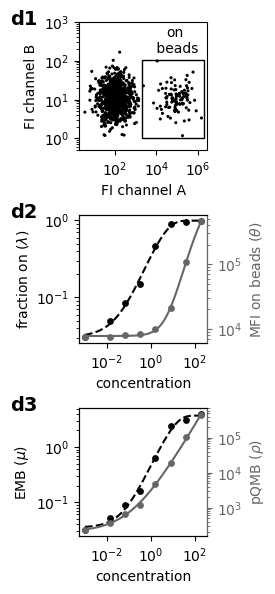

In [19]:
fig, axes = plt.subplots(3,1, figsize=(4, 6), layout='constrained')

ambval='lambda'
meanval='meanp'

gray='0.4'


ax=axes[0]
# Create the scatter plot with color mapped to density
ax.scatter(x, y, s=5, marker='o', edgecolors='none', color='k')

# 4. Customize the plot to mimic FlowJo's appearance
ax.set_facecolor('white')
ax.grid(False)

# Set axes labels and logicle-like scaling
ax.set_xlabel('FI channel A')
ax.set_ylabel('FI channel B')
#ax.set_title('final gating', fontsize=10)

# Create a color bar for the density scale
#cbar = fig.colorbar(ax.collections[0], ax=ax)
#cbar.set_label('Population Density', fontsize=12)

# Set logarithmic scaling for the axes, which is common in flow cytometry
# and can be replicated with a custom SymLogNorm for visualizing events near zero.
# Here, we will use a standard log scale for simplicity.
ax.set_xscale('log')
ax.set_yscale('log')
ax.tick_params(axis='both', which='both', labelsize=10)


rect1 = patches.Rectangle((2*10**3, 1), 2*10**6, 100, linewidth=1, edgecolor='black', facecolor='none')
ax.add_patch(rect1)

ax.text(0.75, 0.85, 'on\n beads', horizontalalignment='center',
     verticalalignment='center', transform=ax.transAxes)

# Adjust plot limits for better visualization
#ax.set_xlim(-4, 14)
ax.set_ylim(.5, 10**3)
ax.set_box_aspect(1)

s=15

for i, (k, df) in enumerate(cals.items()):
  if k=='il17':
    ax=axes[1]
    ax.plot(xf[k,ambval],yf[k,ambval], '--',color='black', label='$\lambda$')
    ax2 = ax.twinx()
    ax2.plot(xf[k,meanval],yf[k,meanval], color=gray, label= '$\theta$')

    ax.scatter(df['conc'],df[ambval], color='black',s=s)
    ax2.scatter(df['conc'],df[meanval], color=gray,s=s)
    #
    ax.set_yscale('log')
    ax2.set_yscale('log')
    ax.set_xscale('log')
    ax.set_ylabel(r'fraction on ($\lambda$)')
    ax2.set_ylabel(r'MFI on beads ($\theta$)', color=gray)
    ax.set_xlabel('concentration')# (pg/mL)')

    # Match MFI axis spine, tick marks, and tick labels to dark gray color
    ax2.tick_params(axis='y', colors=gray, which='both')
    ax2.spines['right'].set_color(gray)

    # Add legend
    #lines1, labels1 = ax.get_legend_handles_labels()
    #lines2, labels2 = ax2.get_legend_handles_labels()
    #ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    
    ax=axes[2]

    ambval='amb'
    ax.plot(xf[k,ambval],yf[k,ambval], '--',color='black')
    ax.scatter(df['conc'],df[ambval], color='black', s=s)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylabel(r'EMB ($\mu$)')
    ax.set_xlabel('concentration')# (pg/mL)')
    

    ambval='mean_all'
    ax2 = ax.twinx()
    ax2.plot(xf[k,ambval],yf[k,ambval], color=gray)
    ax2.scatter(df['conc'],df[ambval], color=gray, s=s)
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_ylabel(r'pQMB ($\rho$)', color=gray)
    ax2.tick_params(axis='y', colors=gray, which='both')
    ax2.spines['right'].set_color(gray)

axes[0].set_box_aspect(1)
axes[1].set_box_aspect(1)
axes[2].set_box_aspect(1)
plt.tight_layout()
#plt.subplots_adjust(hspace=.6) 

# annotate with d1, d2, d3 added to each subplot
for i, ax in enumerate(axes):
    ax.annotate(f'd{i+1}', xy=(0, 1), xycoords='axes fraction',
                xytext=(-30, -5), textcoords='offset points',
                ha='right', va='bottom', fontsize=14, fontweight='bold')


fig.savefig(figure_path+'schematic_digital_analog_flow.pdf')